In [3]:
import pandas as pd

In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/notebooks/tishabhavsar/bias-aware-2/training_logs.csv")
df.head()

,step,task_loss,bias_loss,total_loss,sps
0,0,19.698967,0.136841,19.726341,NaN
1,1,18.504229,0.135498,18.531328,NaN
2,2,16.659702,0.125488,16.684803,NaN
3,3,18.082237,0.145508,18.111336,NaN
4,4,15.280686,0.132202,15.307130,NaN


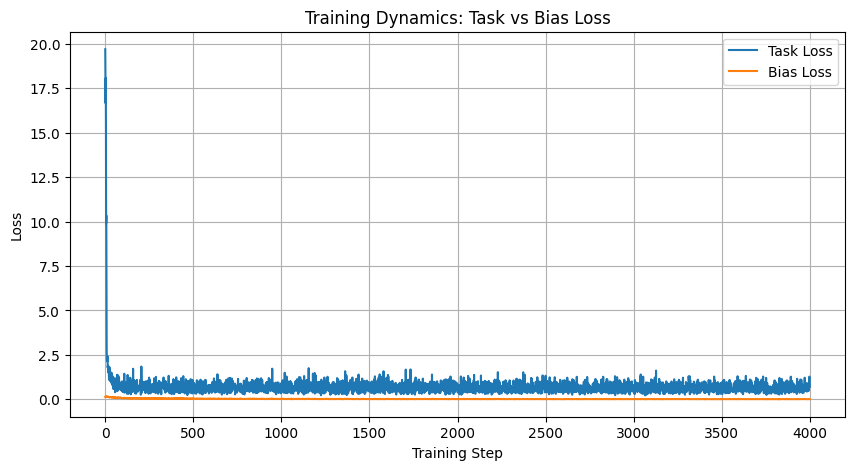

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df["step"], df["task_loss"], label="Task Loss")
plt.plot(df["step"], df["bias_loss"], label="Bias Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Dynamics: Task vs Bias Loss")
plt.legend()
plt.grid()

plt.show()

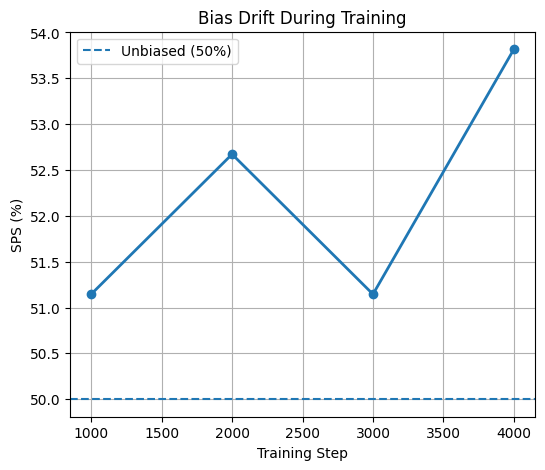

In [6]:
sps_df = df.dropna(subset=["sps"])

plt.figure(figsize=(6,5))

plt.plot(sps_df["step"], sps_df["sps"], marker="o", linewidth=2)

plt.axhline(50, linestyle="--", label="Unbiased (50%)")

plt.xlabel("Training Step")
plt.ylabel("SPS (%)")
plt.title("Bias Drift During Training")
plt.legend()
plt.grid()

plt.show()

### Bias-aware fine-tuning reduces overall bias but does not guarantee stable or monotonic behavioral debiasing, highlighting the limitation of representation-level regularization alone.

In [8]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("hugging-face-access-token")

!pip install -q transformers datasets peft accelerate sentencepiece

from huggingface_hub import login
login(hf_token)

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf",
    torch_dtype=torch.float16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, "/kaggle/input/notebooks/tishabhavsar/bias-aware-2/best_model")
tokenizer = AutoTokenizer.from_pretrained("/kaggle/input/notebooks/tishabhavsar/bias-aware-2/best_model")

model.eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_feat

In [12]:
from datasets import load_dataset

dataset = load_dataset("glue", "sst2", split="validation")

In [13]:
def create_prompt(text):
    return f"Review: {text}\nSentiment:"

In [14]:
def predict(model, tokenizer, text):
    prompt = create_prompt(text)

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False
        )

    generated = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Extract only generated part
    prediction = generated[len(prompt):].strip().lower()

    if "positive" in prediction:
        return 1
    elif "negative" in prediction:
        return 0
    else:
        return -1  # unclear

In [15]:
dataset = dataset.select(range(200))

In [17]:
correct = 0
total = 0
count = 0
curr_accuracy = 0
for example in dataset:
    pred = predict(model, tokenizer, example["sentence"])
    true = example["label"]

    if pred == -1:
        continue

    if pred == true:
        correct += 1
    count +=1 
    print("done with iteration", count)
    total += 1
    curr_accuracy = correct / total

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

done with iteration 1
done with iteration 2
done with iteration 3
done with iteration 4
done with iteration 5
done with iteration 6
done with iteration 7
done with iteration 8
done with iteration 9
done with iteration 10
done with iteration 11
done with iteration 12
done with iteration 13
done with iteration 14
done with iteration 15
done with iteration 16
done with iteration 17
done with iteration 18
done with iteration 19
done with iteration 20
done with iteration 21
done with iteration 22
done with iteration 23
done with iteration 24
done with iteration 25
done with iteration 26
done with iteration 27
done with iteration 28
done with iteration 29
done with iteration 30
done with iteration 31
done with iteration 32
done with iteration 33
done with iteration 34
done with iteration 35
done with iteration 36
done with iteration 37
done with iteration 38
done with iteration 39
done with iteration 40
done with iteration 41
done with iteration 42
done with iteration 43
done with iteration 

In [ ]:
print(f"Accuracy: {accuracy:.4f}")